# DS2002 — Basic Charts from CSV Data

##  Goal
In this notebook, we will learn how to:
- load a CSV file into a pandas DataFrame,
- inspect the structure of the data,
- create basic charts using **matplotlib**,
- compare that experience with **seaborn** and **plotly express**,
- connect charts back to actual business questions.

This notebook is designed for an introductory class and works in **Kaggle**.

---



## Cell 1 explanation
This next code cell imports the main libraries we need.

- **pandas** is used for reading and working with tabular data.
- **matplotlib.pyplot** is the classic plotting library in Python.
- **seaborn** sits on top of matplotlib and usually makes statistical charts easier and prettier.
- **plotly.express** creates interactive charts.

The `%matplotlib inline` line tells Jupyter to display plots directly in the notebook.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

%matplotlib inline

## Cell 2 explanation
Now we read the CSV file into a pandas DataFrame.

A **DataFrame** is the main table structure in pandas.  
Think of it like a spreadsheet that Python can analyze.

In Kaggle, you would usually point this path to a file in `/kaggle/input/...`.  
For this version, the CSV lives in the same working area as the notebook.


In [14]:

df = pd.read_csv("/kaggle/input/datasets/fourfeatherz/ds2002-walmart-clean-sales/ds2002_walmart_clean_sales.csv")
df.head()

,transaction_id,date,store_id,region,category,product,storm_phase,units_sold,unit_price,revenue
0,T100000,2025-09-29,ST004,South,Breakfast Foods,Instant Oatmeal,Normal,16,3.99,63.84
1,T100001,2025-09-03,ST005,South,Breakfast Foods,Instant Oatmeal,Watch,11,3.99,43.89
2,T100002,2025-09-23,ST003,South,Family & Leisure,Playing Cards,Normal,7,2.99,20.93
3,T100003,2025-08-25,ST007,Southeast,Beverages,Orange Juice,Watch,18,4.19,75.42
4,T100004,2025-09-24,ST007,Southeast,Family & Leisure,Playing Cards,Normal,7,2.99,20.93


## Cell 3 explanation
This cell gives us a quick structural overview of the dataset.

- `shape` tells us the number of rows and columns.
- `columns` lists the variable names.
- `dtypes` shows the data type for each column.

This is one of the first things you should do with a new dataset.  
Before making charts, you want to know what kind of data you actually have.


In [15]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (1000, 10)

Columns:
['transaction_id', 'date', 'store_id', 'region', 'category', 'product', 'storm_phase', 'units_sold', 'unit_price', 'revenue']

Data types:
transaction_id     object
date               object
store_id           object
region             object
category           object
product            object
storm_phase        object
units_sold          int64
unit_price        float64
revenue           float64
dtype: object


## Cell 4 explanation
This cell checks for missing values.

Even though this is a clean dataset, it is still a good habit to check.  
In real projects, missing data can quietly distort charts and summaries.

`isnull().sum()` gives the count of missing values in each column.


In [16]:
df.isnull().sum()

transaction_id    0
date              0
store_id          0
region            0
category          0
product           0
storm_phase       0
units_sold        0
unit_price        0
revenue           0
dtype: int64

## Cell 5 explanation
This cell creates summary statistics for the numeric columns.

This helps us answer simple questions such as:
- What is the average number of units sold?
- What is the minimum and maximum revenue?
- Are there values that look unusual?

Descriptive statistics are often the bridge between raw data and visualization.


In [17]:
df.describe()

,units_sold,unit_price,revenue
count,1000.000000,1000.000000,1000.000000
mean,14.935000,6.835810,87.836090
std,7.367568,4.901359,54.373168
min,1.000000,2.290000,7.980000
25%,10.000000,3.490000,48.860000
50%,14.000000,4.390000,73.185000
75%,19.000000,9.290000,112.410000
max,46.000000,19.990000,359.820000


## Cell 6 explanation
Before graphing, we often need a **summary table**.

Here, we group the data by `category` and calculate:
- total units sold,
- average unit price,
- total revenue.

This is important because many visualizations work best on aggregated data rather than raw transactions.


In [18]:
category_summary = (
    df.groupby("category", as_index=False)
      .agg(
          total_units_sold=("units_sold", "sum"),
          average_unit_price=("unit_price", "mean"),
          total_revenue=("revenue", "sum")
      )
      .sort_values("total_units_sold", ascending=False)
)

category_summary

,category,total_units_sold,average_unit_price,total_revenue
0,Beverages,4764,3.990000,19912.16
1,Breakfast Foods,3407,4.189152,14015.67
4,Snacks,2887,3.861667,11141.53
3,Household,2050,10.374118,21037.00
2,Family & Leisure,1827,11.930639,21729.73


# Part 1 — Basic charts with matplotlib

Matplotlib is the foundation.  
It gives us control, but it can feel a little more manual than newer libraries.

We will start with four common chart types:
1. bar chart
2. line chart
3. histogram
4. scatter plot


## Cell 7 explanation: Bar chart with matplotlib
A **bar chart** is useful when you want to compare categories.

Here, each bar represents a product category, and its height shows total units sold.

This is a good chart when the question is:
> Which category sold the most?


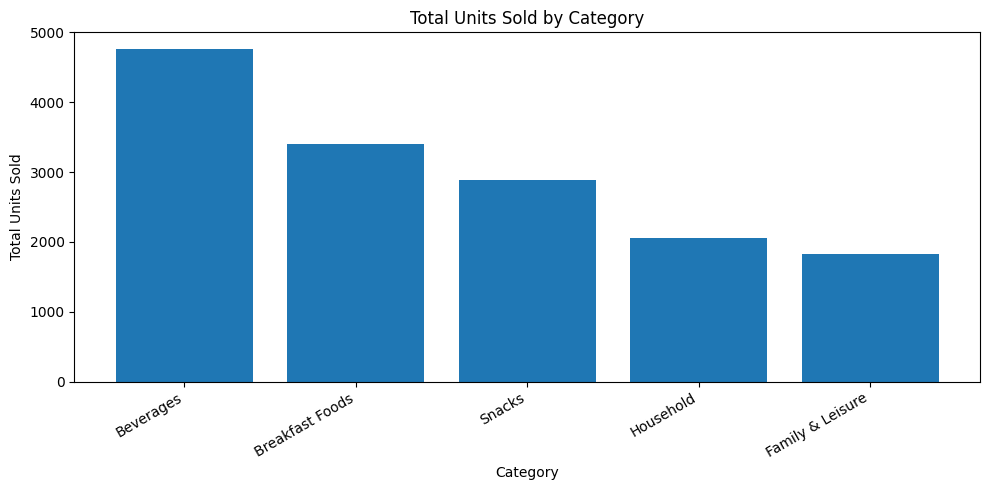

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(category_summary["category"], category_summary["total_units_sold"])
plt.title("Total Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 8 explanation: Line chart with matplotlib
A **line chart** is useful when we want to show change over time.

To build it, we first convert the `date` column into a real datetime format.  
Then we group sales by date and sum the number of units sold.

This is a good chart when the question is:
> How did sales change across time?


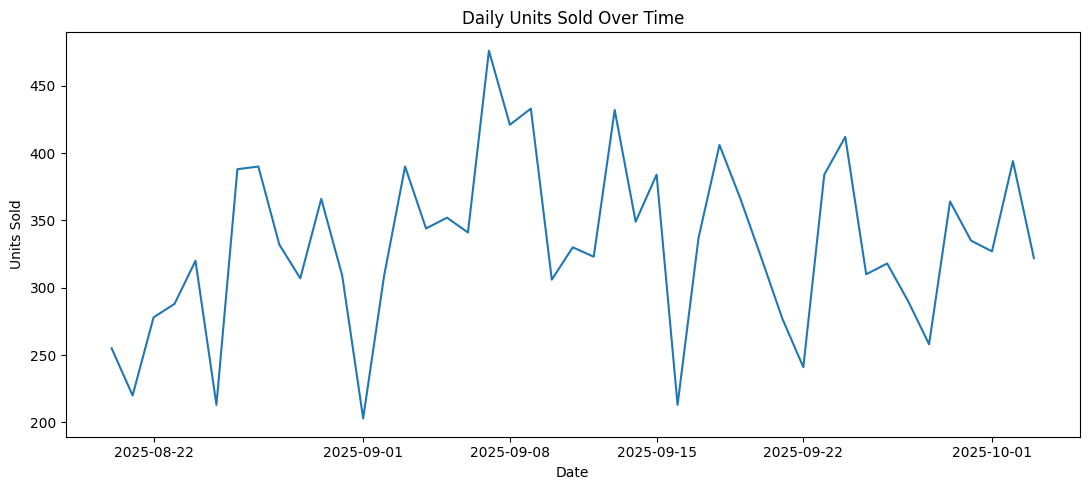

In [20]:
df["date"] = pd.to_datetime(df["date"])

daily_sales = (
    df.groupby("date", as_index=False)["units_sold"]
      .sum()
      .sort_values("date")
)

plt.figure(figsize=(11, 5))
plt.plot(daily_sales["date"], daily_sales["units_sold"])
plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

## Cell 9 explanation: Histogram with matplotlib
A **histogram** helps us understand the distribution of a numeric variable.

Instead of comparing categories, it groups values into bins.  
This makes it useful for questions like:
> Are most transactions small, medium, or large?

In this example, we look at the distribution of `units_sold`.


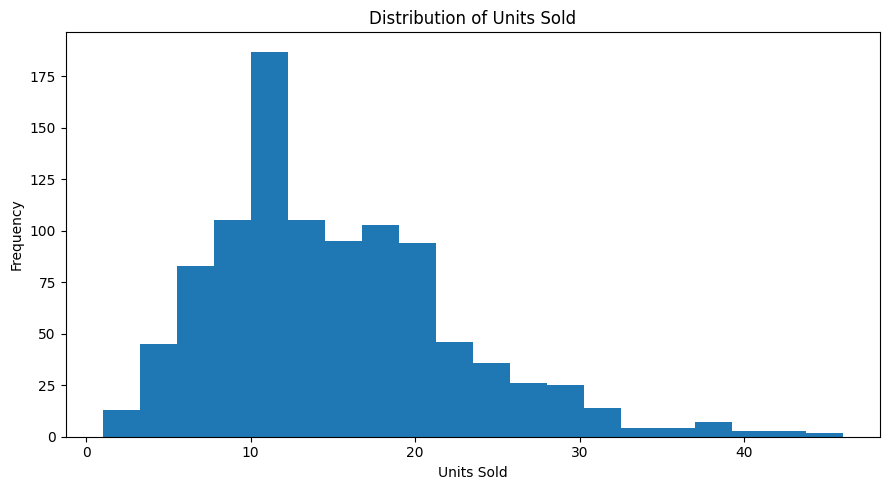

In [21]:
plt.figure(figsize=(9, 5))
plt.hist(df["units_sold"], bins=20)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Cell 10 explanation: Scatter plot with matplotlib
A **scatter plot** shows the relationship between two numeric variables.

Each point is one row in the dataset.  
Here, we compare `units_sold` and `revenue`.

This is useful for asking:
> As units sold increase, does revenue also increase?


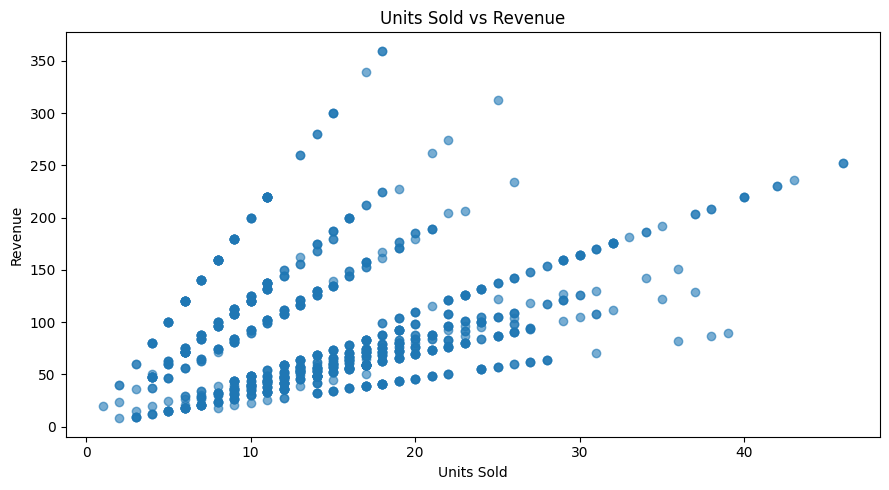

In [22]:
plt.figure(figsize=(9, 5))
plt.scatter(df["units_sold"], df["revenue"], alpha=0.6)
plt.title("Units Sold vs Revenue")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Part 2 — Similar charts with seaborn

Seaborn is built on top of matplotlib.  
It often requires less code for grouped data and statistical charts.

The goal here is not to memorize everything.  
The goal is to notice how the library feels and what kinds of charts it makes easier.


## Cell 11 explanation: Seaborn barplot
This chart is similar to the earlier matplotlib bar chart, but seaborn handles styling and category labels nicely.

Use seaborn when you want a cleaner default look and easier category-based plotting.


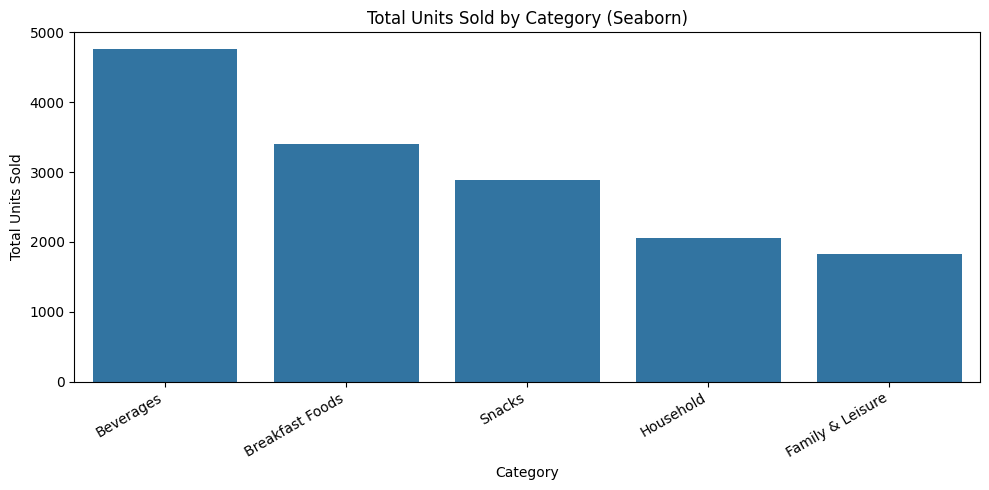

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(data=category_summary, x="category", y="total_units_sold")
plt.title("Total Units Sold by Category (Seaborn)")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 12 explanation: Seaborn boxplot
A **boxplot** helps show the spread of a numeric variable across categories.

It helps answer:
- Which categories have more variation?
- Are there possible outliers?
- Are some categories consistently higher than others?



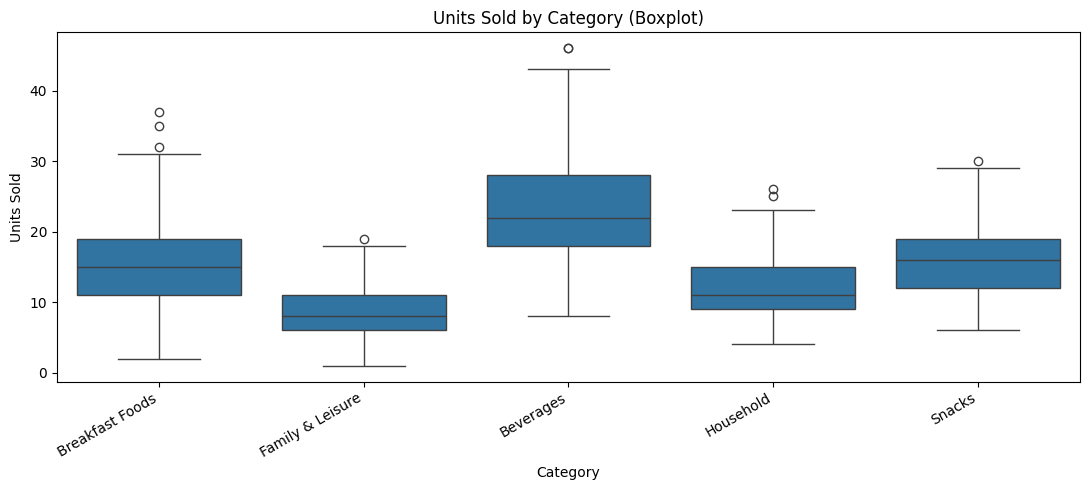

In [25]:
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="category", y="units_sold")
plt.title("Units Sold by Category (Boxplot)")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Cell 13 explanation: Seaborn scatterplot with color grouping
This scatter plot adds a `hue`, which colors the points by category.

That lets us compare multiple groups at once inside the same plot.

This is useful when the question becomes:
> Do some categories follow a different pattern than others?


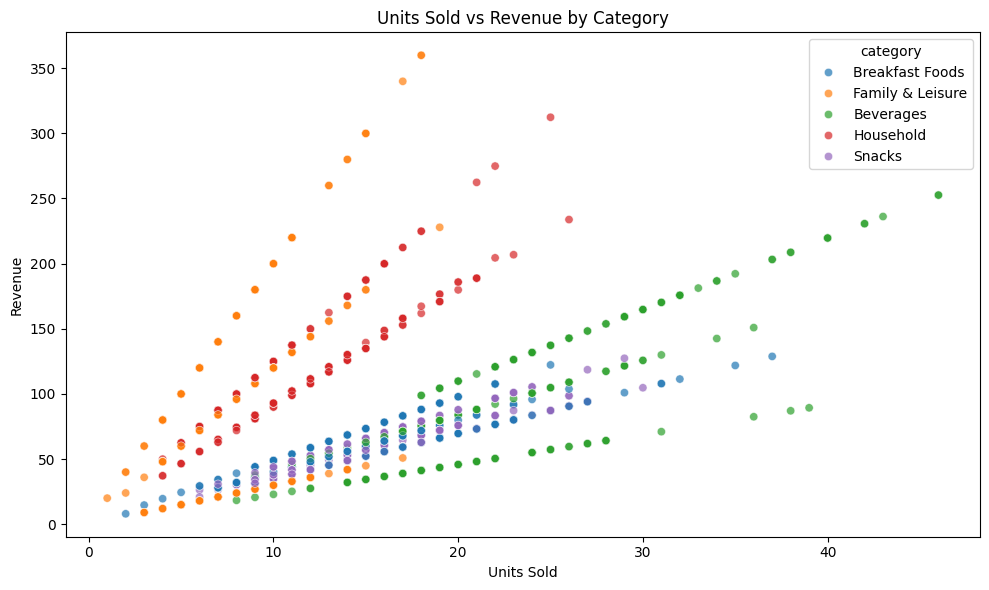

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="units_sold", y="revenue", hue="category", alpha=0.7)
plt.title("Units Sold vs Revenue by Category")
plt.xlabel("Units Sold")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Part 3 — Interactive charts with plotly express

Plotly Express is useful when you want interactive charts:
- hover labels,
- zooming,
- easier exploration.

This is especially nice in Kaggle because students can mouse over the graph and inspect values.


## Cell 14 explanation: Interactive bar chart
This chart shows total revenue by category.

The main difference is that the result is interactive.  
You can hover over bars to inspect exact values.


In [28]:
revenue_summary = (
    df.groupby("category", as_index=False)["revenue"]
      .sum()
      .sort_values("revenue", ascending=False)
)

fig = px.bar(
    revenue_summary,
    x="category",
    y="revenue",
    title="Total Revenue by Category (Plotly Express)"
)
fig.show()

## Cell 15 explanation: Interactive scatter plot
This scatter plot lets us explore individual records interactively.

We color points by `storm_phase` to show how another variable can add context.


In [29]:
fig = px.scatter(
    df,
    x="units_sold",
    y="revenue",
    color="storm_phase",
    hover_data=["product", "store_id", "region"],
    title="Units Sold vs Revenue by Storm Phase"
)
fig.show()

# Part 4 — A few practical filters

Charts become more useful when you can ask targeted questions.

In the next few cells, we filter the dataset and then graph the filtered result.  
This is closer to what students will actually do in real work.


## Cell 16 explanation: Filter to one product
This cell filters the data to only rows where the product is `Strawberry Pop-Tarts`.

This is useful when the business question is focused on one product rather than the whole dataset.


In [30]:
poptarts_df = df[df["product"] == "Strawberry Pop-Tarts"]
poptarts_df.head()

,transaction_id,date,store_id,region,category,product,storm_phase,units_sold,unit_price,revenue
5,T100005,2025-09-26,ST009,Southeast,Breakfast Foods,Strawberry Pop-Tarts,Watch,20,3.48,69.60
40,T100040,2025-08-20,ST003,South,Breakfast Foods,Strawberry Pop-Tarts,Normal,26,3.48,90.48
44,T100044,2025-09-15,ST007,Southeast,Breakfast Foods,Strawberry Pop-Tarts,Watch,27,3.48,93.96
50,T100050,2025-09-23,ST001,South,Breakfast Foods,Strawberry Pop-Tarts,Normal,14,3.48,48.72
66,T100066,2025-08-28,ST012,Midwest,Breakfast Foods,Strawberry Pop-Tarts,Normal,16,3.48,55.68


## Cell 17 explanation: Trend chart for one product
Now we group the filtered data by date and create a line chart.

This is a very common workflow:
1. filter rows,
2. aggregate,
3. visualize.


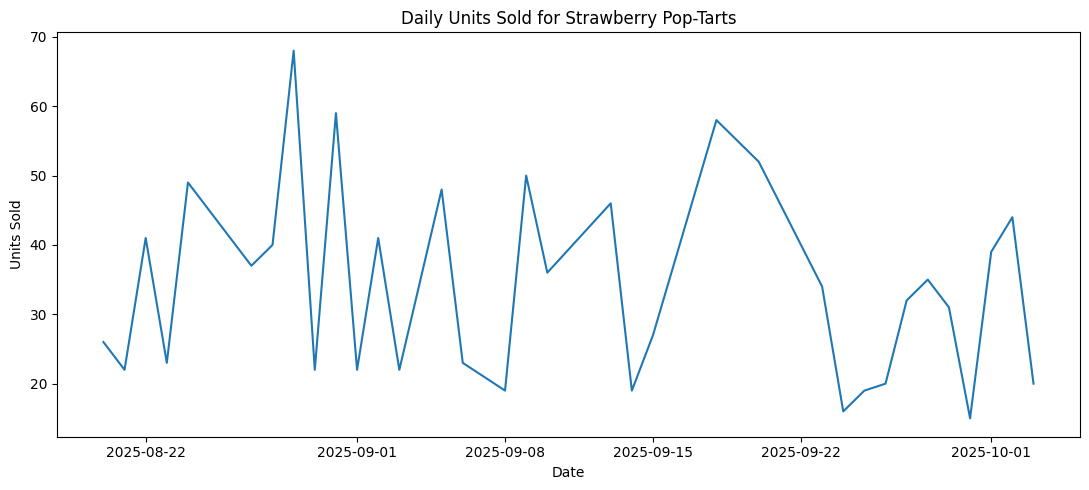

In [31]:
poptarts_daily = (
    poptarts_df.groupby("date", as_index=False)["units_sold"]
               .sum()
               .sort_values("date")
)

plt.figure(figsize=(11, 5))
plt.plot(poptarts_daily["date"], poptarts_daily["units_sold"])
plt.title("Daily Units Sold for Strawberry Pop-Tarts")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

## Cell 18 explanation: Compare regions
Here we compare total revenue by region.

This is a simple example of categorical comparison, and it shows how a bar chart can answer a location-based business question.


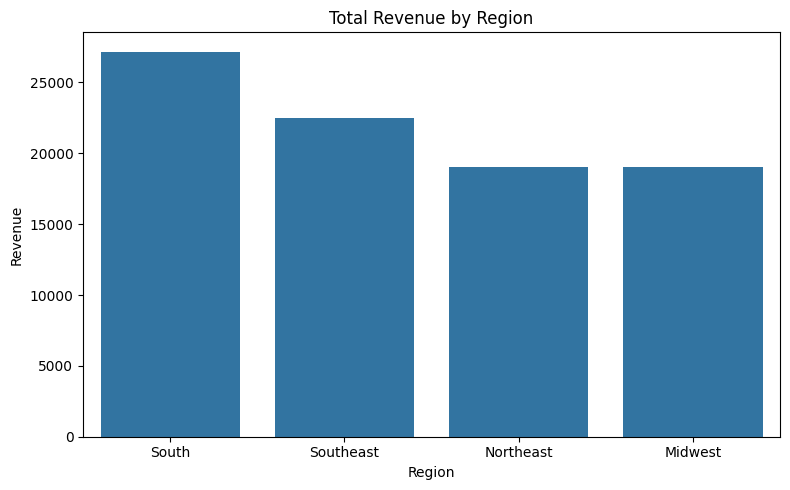

In [32]:
region_summary = (
    df.groupby("region", as_index=False)["revenue"]
      .sum()
      .sort_values("revenue", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=region_summary, x="region", y="revenue")
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Wrap-up

## Take away
By the end of this notebook, students should be able to:
- load a CSV into pandas,
- inspect a dataset before plotting,
- summarize data with `groupby`,
- create basic charts with matplotlib,
- recognize how seaborn and plotly differ,
- choose a chart that matches the question being asked.

